# Survival Analysis Model Benchmark

**Bachelor Thesis: Application of ML Models in Survival Analysis**

This notebook implements the full experimental pipeline:

1. **Data Loading** - 4 benchmark datasets (GBSG2, METABRIC, DLBCL, SUPPORT)
2. **Exploratory Analysis** - KM curves, distributions, correlations
3. **Quick Benchmark** - 80/20 split with default hyperparameters
4. **Nested Cross-Validation** - 5x5 CV with HP tuning
5. **Visualizations** - heatmaps, rank charts, calibration, Brier-over-time
6. **Interpretability** - SurvLIME + SurvSHAP(t) on synthetic data with known ground truth

**Models (4):** CoxPH, CoxNet (elastic-net), RSF, DeepSurv

**Datasets:**

| Dataset | n | p | Source | Challenge |
|---------|---|---|--------|-----------|
| GBSG2 | 686 | 9 | scikit-survival | Clean, low-dim baseline |
| METABRIC | 1,904 | 9 | pycox | Popular DL benchmark |
| DLBCL | 240 | 7,399 | SurvSet | High-dim omics (p >> n) |
| SUPPORT | 8,873 | 14 | pycox | Large-n, scalability |

In [1]:
import sys, os, time
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from lifelines import KaplanMeierFitter
from sklearn.model_selection import train_test_split

from src.data import LOADERS, SurvivalData, generate_interpretability_data
from src.models import ALL_MODELS
from src.benchmark.runner import BenchmarkRunner
from src.benchmark.nested_cv_runner import NestedCVRunner
from src.evaluation.metrics import (
    evaluate_model, concordance_index, concordance_index_ipcw,
    integrated_brier_score, time_dependent_auc, calibration_curve,
)
from src.evaluation.visualizations import (
    plot_metric_heatmap, plot_rank_chart, plot_brier_score_over_time,
)

sns.set_theme(style='whitegrid', palette='colorblind')
SEED = 42
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(exist_ok=True)

print(f'Datasets: {list(LOADERS.keys())}')
print(f'Models:   {list(ALL_MODELS.keys())}')

Datasets: ['gbsg2', 'metabric', 'dlbcl', 'support']
Models:   ['cox_ph', 'cox_net', 'rsf', 'deep_surv']


---
## 1. Data Loading & Exploratory Analysis

In [2]:
# Load all datasets
datasets = {name: loader() for name, loader in LOADERS.items()}

for name, data in datasets.items():
    print(data.summary())
    print()

Dataset: gbsg2
  n=686, p=9
  censoring rate: 56.4%
  median observed time: 1084.000
  event count: 299

Dataset: metabric
  n=1904, p=9
  censoring rate: 42.1%
  median observed time: 114.900
  event count: 1103

Dataset: dlbcl
  n=240, p=7399
  censoring rate: 42.5%
  median observed time: 2.801
  event count: 138

Dataset: support
  n=8873, p=14
  censoring rate: 32.0%
  median observed time: 231.000
  event count: 6036



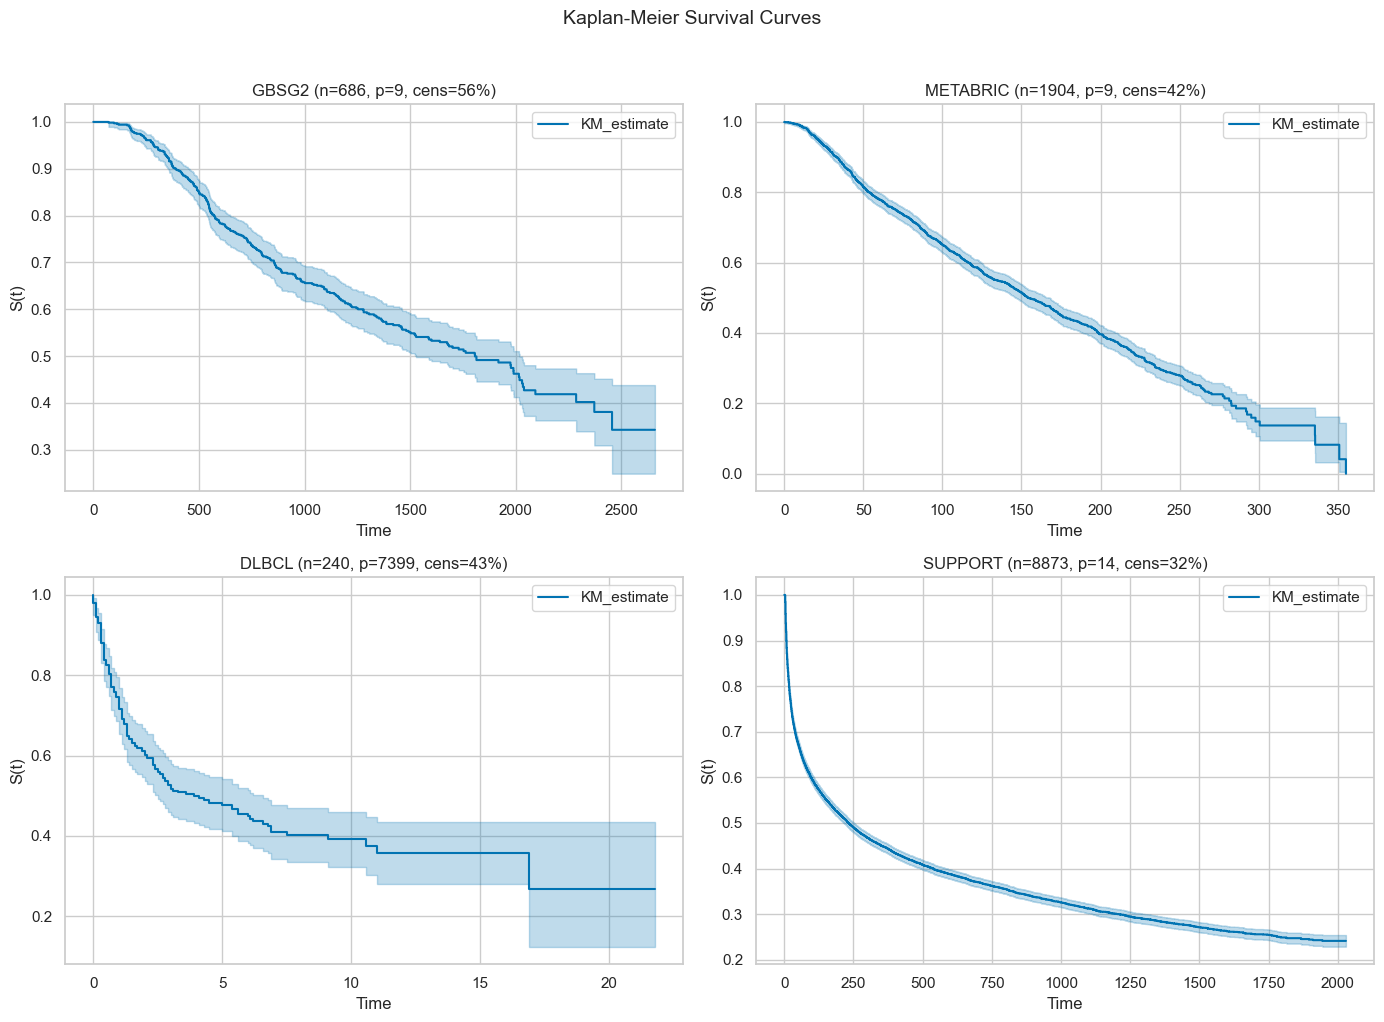

In [3]:
# Kaplan-Meier survival curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
kmf = KaplanMeierFitter()

for ax, (name, data) in zip(axes.flat, datasets.items()):
    kmf.fit(data.T, event_observed=data.E)
    kmf.plot_survival_function(ax=ax, ci_show=True)
    ax.set_title(f'{name.upper()} (n={data.n}, p={data.p}, cens={data.censoring_rate:.0%})')
    ax.set_xlabel('Time')
    ax.set_ylabel('S(t)')

fig.suptitle('Kaplan-Meier Survival Curves', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

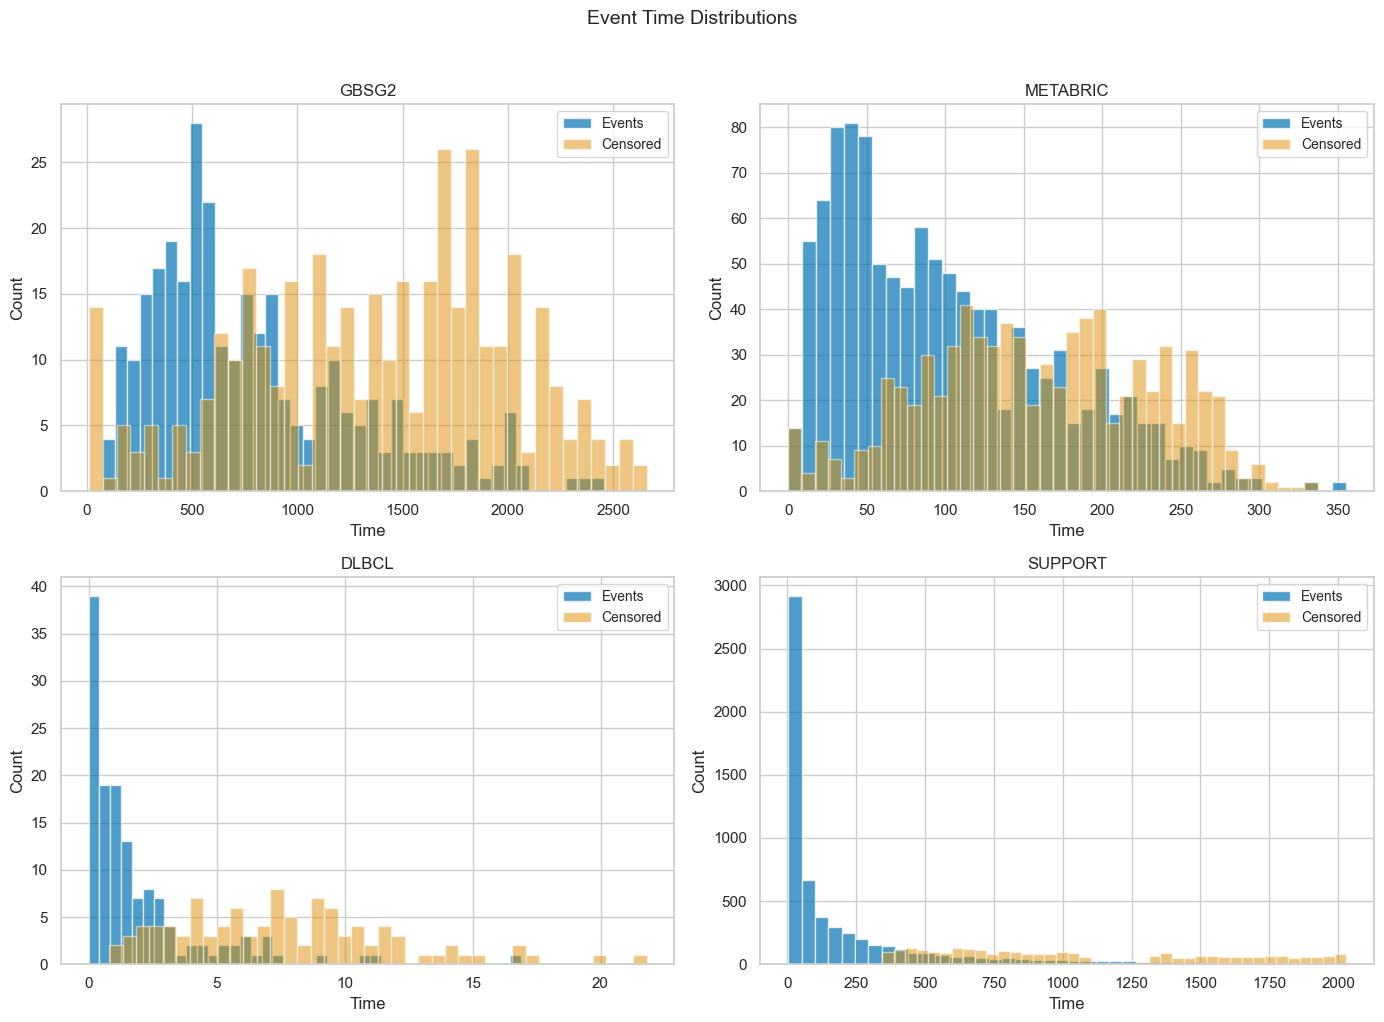

In [4]:
_pal = sns.color_palette('colorblind')
# Event time distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, data) in zip(axes.flat, datasets.items()):
    events = data.T[data.E == 1]
    censored = data.T[data.E == 0]
    ax.hist(events, bins=40, alpha=0.7, label='Events', color=_pal[0])
    ax.hist(censored, bins=40, alpha=0.5, label='Censored', color=_pal[1])
    ax.set_title(f'{name.upper()}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Count')
    ax.legend(fontsize='small')

fig.suptitle('Event Time Distributions', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

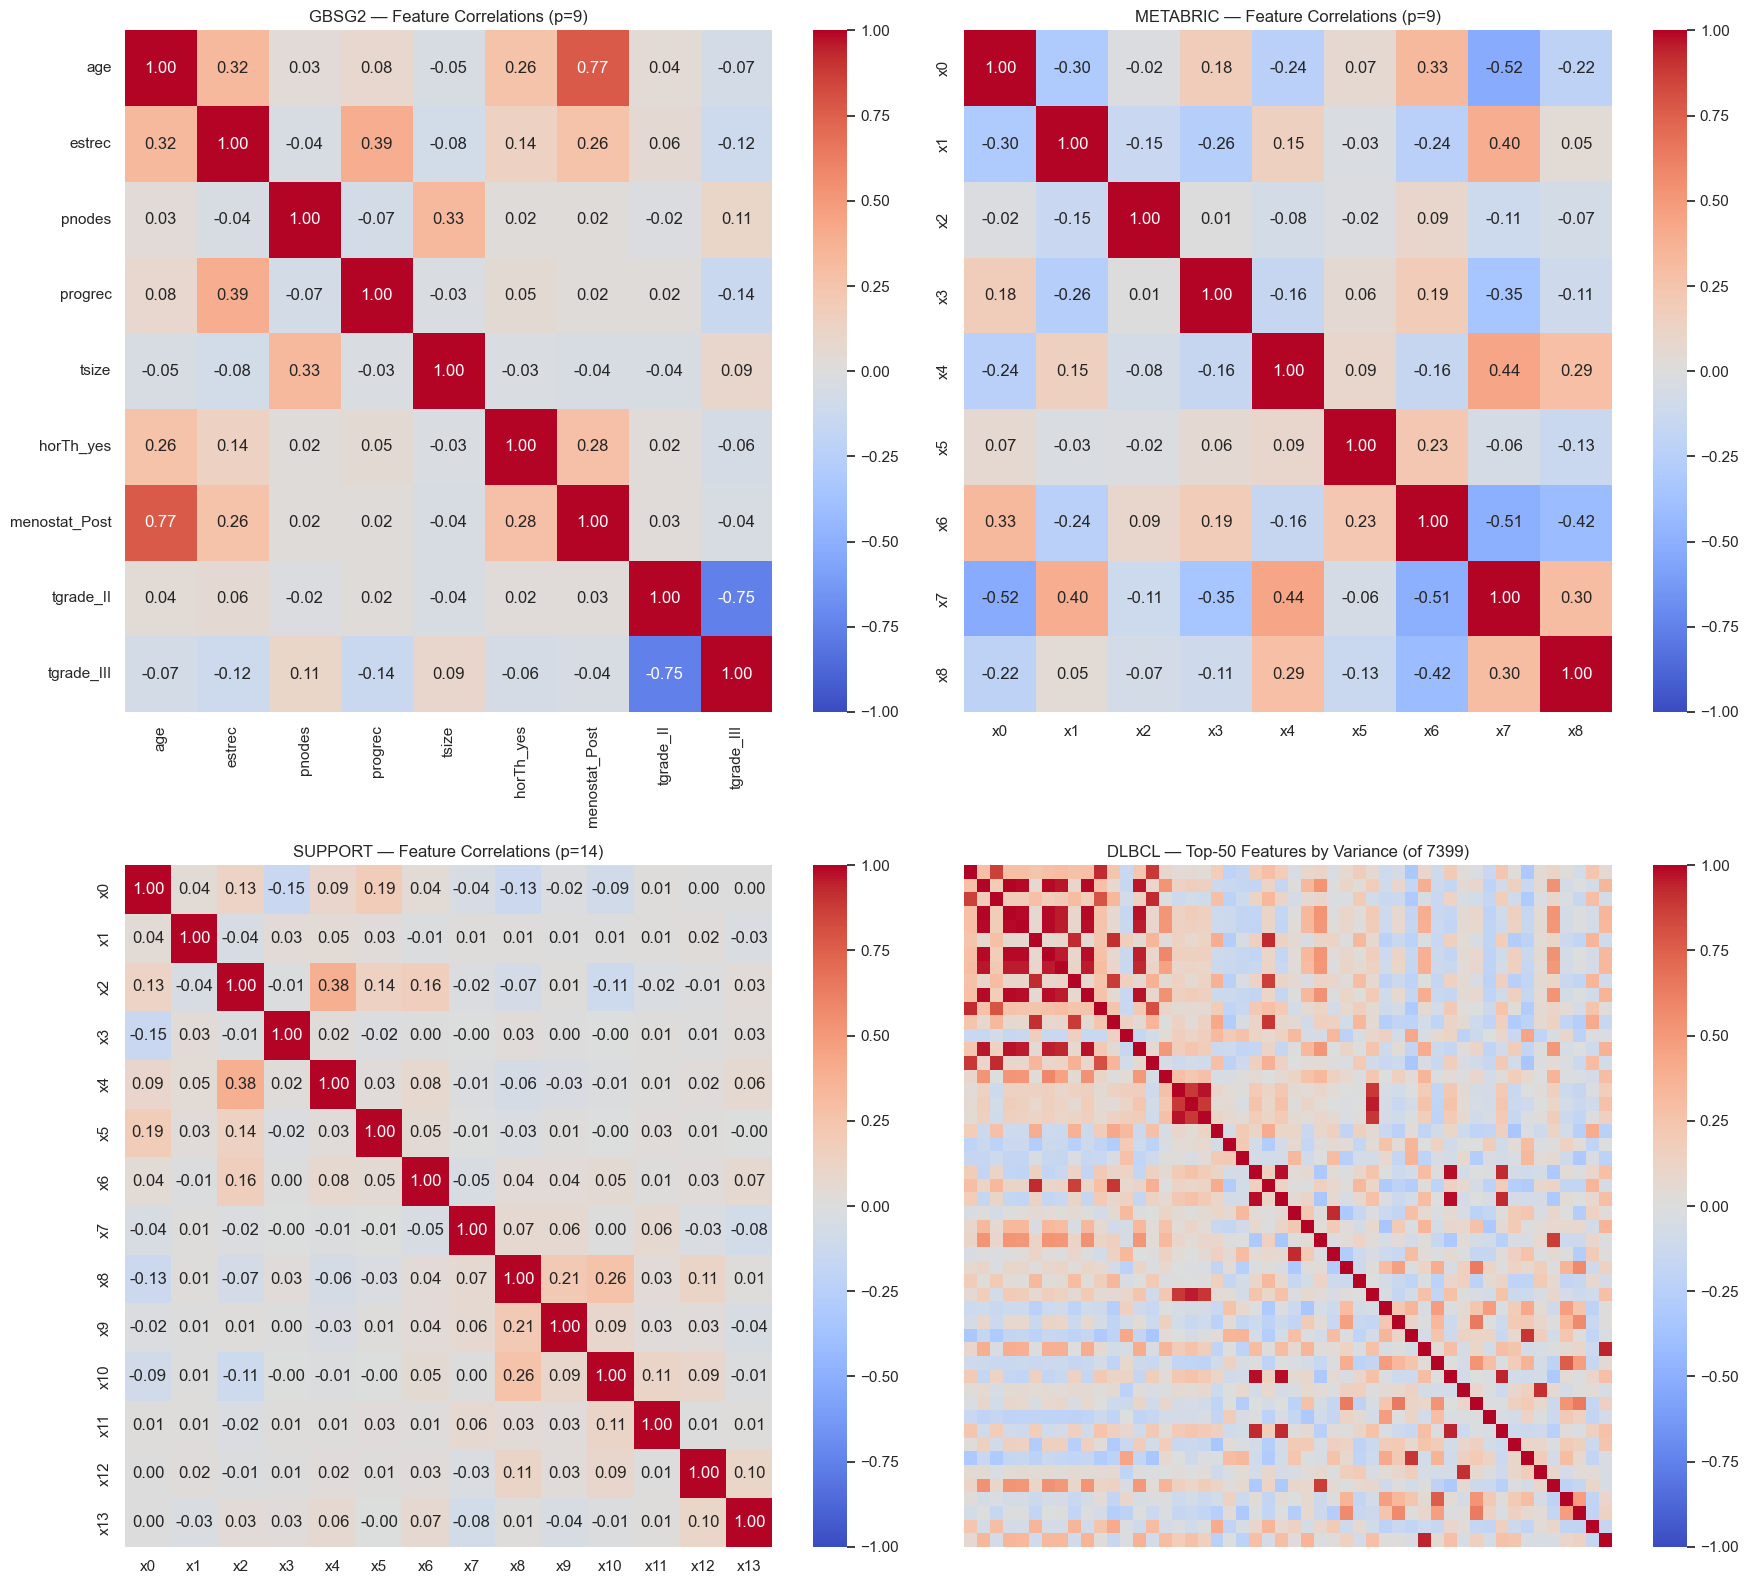

In [5]:
# Correlation heatmaps - all 4 datasets
# Low-dim (GBSG2, METABRIC, SUPPORT): full matrix with annotations
# High-dim (DLBCL): top-50 features by variance, no tick labels

fig, axes = plt.subplots(2, 2, figsize=(18, 16))

for ax, ds_name in zip(axes.flat, ['gbsg2', 'metabric', 'support', 'dlbcl']):
    d = datasets[ds_name]
    if d.p > 50:
        # High-dim: select top-50 by variance
        var_order = np.argsort(d.X.var(axis=0))[::-1][:50]
        corr = np.corrcoef(d.X[:, var_order].T)
        sns.heatmap(corr, ax=ax, cmap='coolwarm', center=0, vmin=-1, vmax=1,
                    xticklabels=False, yticklabels=False)
        ax.set_title(f'{ds_name.upper()} — Top-50 Features by Variance (of {d.p})')
    else:
        corr = np.corrcoef(d.X.T)
        annot = d.p <= 15  # annotate only if few enough features
        sns.heatmap(corr, ax=ax, cmap='coolwarm', center=0, vmin=-1, vmax=1,
                    xticklabels=d.feature_names, yticklabels=d.feature_names,
                    annot=annot, fmt='.2f')
        ax.set_title(f'{ds_name.upper()} — Feature Correlations (p={d.p})')

fig.tight_layout()
plt.show()

### Proportional Hazards Assumption Test (Schoenfeld Residuals)

The Cox PH model assumes that hazard ratios are **constant over time**. We test this using Schoenfeld residuals (lifelines `proportional_hazard_test`):
- **p > 0.05** -> PH holds for this feature
- **p <= 0.05** -> time-varying effect detected (PH violated)

A significant global test suggests Cox PH is mis-specified for that dataset, giving tree-based and deep models an advantage.

For **DLBCL** (p=7,399 >> n=240) unpenalised Cox cannot be fitted directly, so we use a **screen-then-test** approach: fit CoxNet (elastic-net Cox), keep the features with non-zero coefficients on a sparse alpha (<= n_events / 10 features as a rule of thumb), refit a low-dimensional Cox on those features, and run the Schoenfeld test on the selected subset.

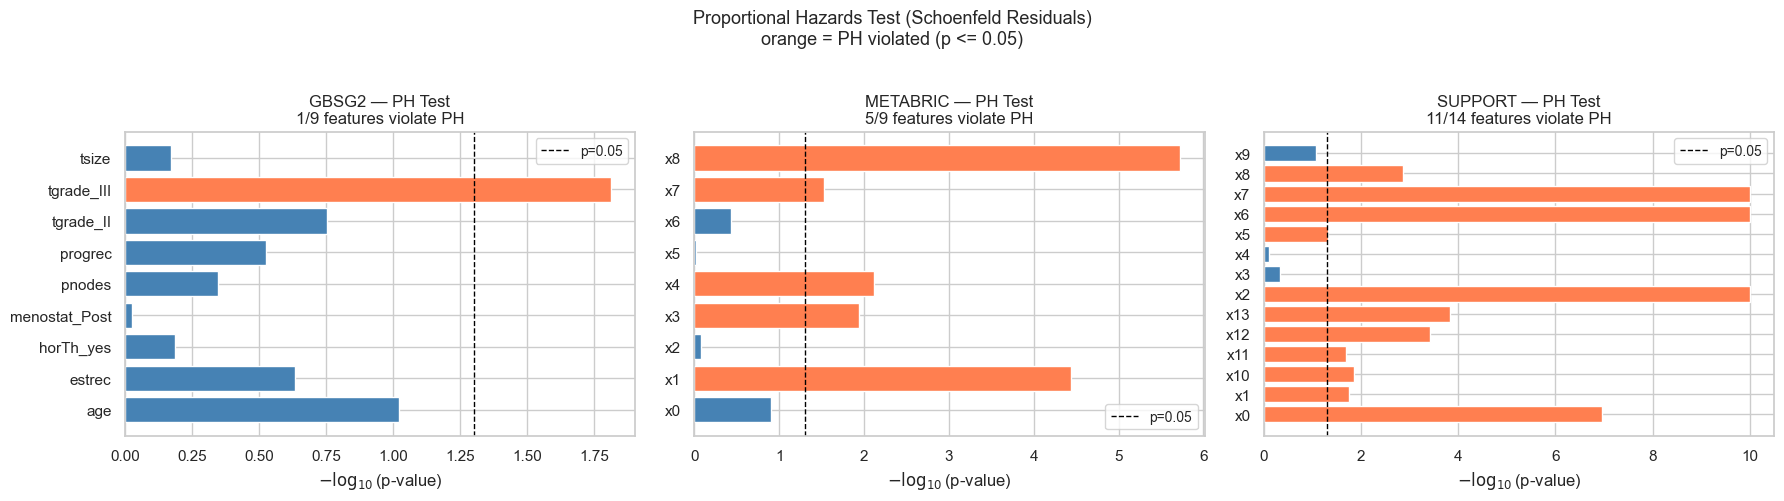


Summary:
  GBSG2     : 1/9 features  min p=0.0155  -> PH likely violated
  METABRIC  : 5/9 features  min p=0.0000  -> PH likely violated
  SUPPORT   : 11/14 features  min p=0.0000  -> PH likely violated


In [6]:
colors = sns.color_palette('colorblind')
# Schoenfeld residuals PH test - all datasets except DLBCL (p >> n, Cox not applicable)
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test

ph_results = {}

for ds_name in ['gbsg2', 'metabric', 'support']:
    d = datasets[ds_name]
    df = pd.DataFrame(d.X, columns=d.feature_names)
    df['T'] = d.T
    df['E'] = d.E.astype(int)

    cph = CoxPHFitter()
    cph.fit(df, duration_col='T', event_col='E')

    result = proportional_hazard_test(cph, df, time_transform='rank')
    summary = result.summary[['test_statistic', 'p']].copy()
    summary.index.name = 'covariate'
    summary = summary.reset_index()
    summary['significant'] = summary['p'] <= 0.05
    ph_results[ds_name] = summary

# Plot: -log10(p) bar chart per dataset
n_rows = max(len(v) for v in ph_results.values())
fig, axes = plt.subplots(1, 3, figsize=(18, max(4, n_rows * 0.35)))

for ax, (ds_name, summary) in zip(axes, ph_results.items()):
    df_plot = summary.sort_values('covariate')
    bar_colors = ['coral' if sig else 'steelblue' for sig in df_plot['significant']]
    ax.barh(df_plot['covariate'], -np.log10(df_plot['p'].clip(lower=1e-10)), color=bar_colors)
    ax.axvline(-np.log10(0.05), color='black', linestyle='--', linewidth=1, label='p=0.05')
    ax.set_xlabel(r'$-\log_{10}$(p-value)')
    n_viol = summary['significant'].sum()
    ax.set_title(f'{ds_name.upper()} — PH Test\n{n_viol}/{len(summary)} features violate PH')
    ax.legend(fontsize='small')

fig.suptitle('Proportional Hazards Test (Schoenfeld Residuals)\norange = PH violated (p <= 0.05)',
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

print('\nSummary:')
for ds_name, summary in ph_results.items():
    n_viol = summary['significant'].sum()
    min_p = summary['p'].min()
    verdict = 'PH likely violated' if n_viol > 0 else 'PH holds'
    print(f'  {ds_name.upper():10s}: {n_viol}/{len(summary)} features  min p={min_p:.4f}  -> {verdict}')

In [7]:
# DLBCL PH test via CoxNet feature selection (p >> n workaround)
# 1) Fit CoxNet -> sparse feature set
# 2) Walk alpha path, pick the densest column with <= n_events/10 non-zero features
# 3) Refit low-dim Cox on selected features and run Schoenfeld
from src.models.cox_net import CoxNetModel

d = datasets['dlbcl']
n_events = int(d.E.sum())
max_feats = max(2, n_events // 10)  # 10 events per parameter rule of thumb

coxnet = CoxNetModel()
coxnet.fit(d.X, d.T, d.E)

all_coefs = coxnet._model.coef_  # (p, n_alphas), columns sorted from large -> small alpha
selected_idx = None
for col in range(all_coefs.shape[1]):
    nz = np.where(all_coefs[:, col] != 0)[0]
    if 2 <= len(nz) <= max_feats:
        selected_idx = nz  # keep walking; we want the densest set still <= max_feats
    elif len(nz) > max_feats:
        break

if selected_idx is None or len(selected_idx) < 2:
    # Fallback: top-k by |coef| at smallest alpha
    final = all_coefs[:, -1]
    order = np.argsort(np.abs(final))[::-1]
    selected_idx = order[:max_feats]
    selected_idx = selected_idx[np.abs(final[selected_idx]) > 0]

selected_names = [d.feature_names[i] for i in selected_idx]
print(f'CoxNet selected {len(selected_idx)} / {d.p} features '
      f'(cap = n_events/10 = {max_feats}; n_events = {n_events})')

df = pd.DataFrame(d.X[:, selected_idx], columns=selected_names)
df['T'] = d.T
df['E'] = d.E.astype(int)

cph = CoxPHFitter(penalizer=1e-4)  # tiny ridge for numerical stability on correlated genes
cph.fit(df, duration_col='T', event_col='E')

result = proportional_hazard_test(cph, df, time_transform='rank')
summary = result.summary[['test_statistic', 'p']].copy()
summary.index.name = 'covariate'
summary = summary.reset_index()
summary['significant'] = summary['p'] <= 0.05
ph_results['dlbcl'] = summary

fig, ax = plt.subplots(figsize=(9, max(4, len(summary) * 0.3)))
df_plot = summary.sort_values('p')
bar_colors = ['coral' if sig else 'steelblue' for sig in df_plot['significant']]
ax.barh(df_plot['covariate'], -np.log10(df_plot['p'].clip(lower=1e-10)), color=bar_colors)
ax.axvline(-np.log10(0.05), color='black', linestyle='--', linewidth=1, label='p=0.05')
ax.set_xlabel(r'$-\log_{10}$(p-value)')
n_viol = int(summary['significant'].sum())
ax.set_title(f'DLBCL - PH Test (CoxNet-selected features)
'
             f'{n_viol}/{len(summary)} features violate PH')
ax.legend(fontsize='small')
plt.tight_layout()
plt.show()

min_p = float(summary['p'].min())
verdict = 'PH likely violated' if n_viol > 0 else 'PH holds'
print(f'
DLBCL: {n_viol}/{len(summary)} features  min p={min_p:.4f}  -> {verdict}')


SyntaxError: unterminated f-string literal (detected at line 55) (1748225221.py, line 55)

---
## 2. Quick Benchmark (Train/Test Split)

Simple 80/20 stratified split with default hyperparameters - a fast smoke test before the full nested CV.

CoxPH is skipped for DLBCL (p=7,399 >> n=240).

In [ ]:
all_model_instances = [cls() for cls in ALL_MODELS.values()]

runner = BenchmarkRunner(
    models=all_model_instances,
    datasets=list(LOADERS.keys()),
    seed=SEED,
)

t0 = time.perf_counter()
bench_results = runner.run(verbose=True)
print(f'\nTotal benchmark time: {time.perf_counter() - t0:.1f}s')


Dataset: gbsg2
Dataset: gbsg2
  n=686, p=8
  censoring rate: 56.4%
  median observed time: 1084.000
  event count: 299

  Fitting CoxPH ...
  CoxPH:
    fit time: 0.02s
    c_index: 0.6968
    c_index_ipcw: 0.6491
    ibs: 0.1640
    mean_auc: 0.7409

  Fitting CoxNet ...
  CoxNet:
    fit time: 0.10s
    c_index: 0.7034
    c_index_ipcw: 0.6731
    ibs: 0.1676
    mean_auc: 0.7471

  Fitting RSF ...
  RSF:
    fit time: 0.09s
    c_index: 0.6914
    c_index_ipcw: 0.6488
    ibs: 0.1608
    mean_auc: 0.7372

  Fitting DeepSurv ...
  DeepSurv:
    fit time: 1.18s
    c_index: 0.6875
    c_index_ipcw: 0.6384
    ibs: 0.1643
    mean_auc: 0.7181

Dataset: metabric
Dataset: metabric
  n=1904, p=9
  censoring rate: 42.1%
  median observed time: 114.900
  event count: 1103

  Fitting CoxPH ...
  CoxPH:
    fit time: 0.08s
    c_index: 0.6274
    c_index_ipcw: 0.6433
    ibs: nan
    mean_auc: nan

  Fitting CoxNet ...
  CoxNet:
    fit time: 0.23s
    c_index: 0.5826
    c_index_ipcw: 0.610

In [ ]:
# Results table
df_bench = bench_results.to_dataframe()
display_cols = [c for c in ['setup', 'model', 'c_index', 'c_index_ipcw', 'ibs', 'mean_auc', 'fit_time_s']
                if c in df_bench.columns]
df_bench[display_cols].style.format({
    'c_index': '{:.4f}', 'c_index_ipcw': '{:.4f}',
    'ibs': '{:.4f}', 'mean_auc': '{:.4f}', 'fit_time_s': '{:.2f}'
}).background_gradient(subset=['c_index_ipcw'], cmap='Greens')

,setup,model,c_index,c_index_ipcw,ibs,mean_auc,fit_time_s
0,dlbcl,CoxNet,0.6623,0.6615,0.3472,0.6597,0.35
1,dlbcl,CoxPH,nan,nan,nan,nan,nan
2,dlbcl,DeepSurv,0.6383,0.6415,0.2191,0.6182,0.07
3,dlbcl,RSF,0.5792,0.5842,0.2252,0.5674,0.39
4,gbsg2,CoxNet,0.7034,0.6731,0.1676,0.7471,0.10
5,gbsg2,CoxPH,0.6968,0.6491,0.1640,0.7409,0.02
6,gbsg2,DeepSurv,0.6875,0.6384,0.1643,0.7181,1.18
7,gbsg2,RSF,0.6914,0.6488,0.1608,0.7372,0.09
8,metabric,CoxNet,0.5826,0.6109,nan,nan,0.23
9,metabric,CoxPH,0.6274,0.6433,nan,nan,0.08


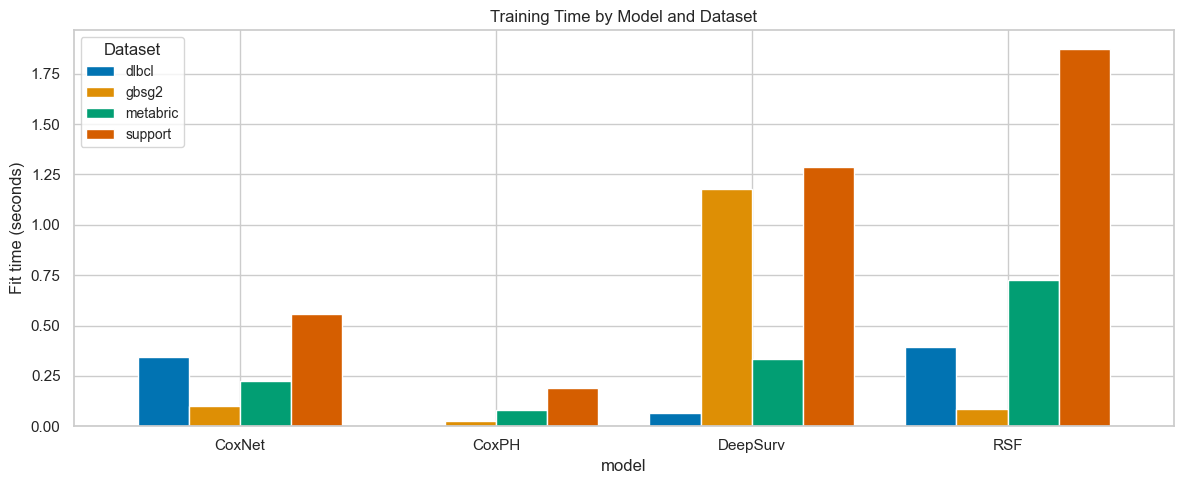

In [ ]:
# Fit time comparison
if 'fit_time_s' in df_bench.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    pivot_time = df_bench.pivot_table(index='model', columns='setup', values='fit_time_s')
    pivot_time.plot(kind='bar', ax=ax, width=0.8)
    ax.set_ylabel('Fit time (seconds)')
    ax.set_title('Training Time by Model and Dataset')
    ax.legend(fontsize='small', title='Dataset')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    fig.tight_layout()
    plt.show()

---
## 3. Nested Cross-Validation with Hyperparameter Tuning

Nested 5x5 CV: outer folds for unbiased evaluation, inner folds for HP selection via random search. This is the main evaluation protocol - results here are reported in the thesis.

In [ ]:
CV_CACHE_DIR = RESULTS_DIR / 'hp_cache'
CV_RAW_CSV   = RESULTS_DIR / 'nested_cv_raw.csv'

if CV_RAW_CSV.exists():
    # Fast path: restore from saved CSV
    from src.benchmark.cv_results import CVResultsTable
    cv_results = CVResultsTable.from_dataframe(pd.read_csv(CV_RAW_CSV))
    print(f'Loaded CV results from {CV_RAW_CSV}')
else:
    # Slow path: run nested CV (HPs cached per fold -> safe to restart)
    cv_runner = NestedCVRunner(
        model_names=list(ALL_MODELS.keys()),
        datasets=list(LOADERS.keys()),
        n_outer_folds=5,
        n_inner_folds=3,
        n_repeats=1,
        inner_metric='c_index_ipcw',
        seed=SEED,
        cache_dir=CV_CACHE_DIR,
    )

    t0 = time.perf_counter()
    cv_results = cv_runner.run(verbose=True)
    print(f'\nNested CV total time: {time.perf_counter() - t0:.1f}s')

    # Save immediately so next run is instant
    cv_df = cv_results.to_dataframe()
    cv_df.to_csv(str(CV_RAW_CSV), index=False)
    print(f'Saved: {CV_RAW_CSV}')

In [ ]:
# Formatted results table (mean +/- SD)
fmt_table = cv_results.format_table()
display(fmt_table)

print('\n--- LaTeX ---')
print(fmt_table.to_latex(index=False))

,setup,model,n_samples,c_index,c_index_ipcw,ibs,mean_auc,fit_time_s
0,dlbcl,CoxNet,240,0.635 +/- 0.026,0.622 +/- 0.016,0.355 +/- 0.082,0.681 +/- 0.017,0.541 +/- 0.672
1,dlbcl,CoxPH,240,N/A,N/A,N/A,N/A,N/A
2,dlbcl,DeepSurv,240,0.647 +/- 0.043,0.634 +/- 0.034,0.232 +/- 0.029,0.698 +/- 0.055,0.295 +/- 0.250
3,dlbcl,RSF,240,0.633 +/- 0.015,0.616 +/- 0.014,0.216 +/- 0.024,0.670 +/- 0.035,3.424 +/- 4.143
4,gbsg2,CoxNet,686,0.672 +/- 0.047,0.653 +/- 0.048,0.187 +/- 0.003,0.719 +/- 0.050,0.111 +/- 0.021
5,gbsg2,CoxPH,686,0.675 +/- 0.051,0.663 +/- 0.049,0.181 +/- 0.002,0.724 +/- 0.056,0.039 +/- 0.006
6,gbsg2,DeepSurv,686,0.617 +/- 0.008,0.607 +/- 0.025,0.199 +/- 0.005,0.656 +/- 0.010,0.229 +/- 0.189
7,gbsg2,RSF,686,0.687 +/- 0.043,0.678 +/- 0.037,0.179 +/- 0.003,0.747 +/- 0.039,0.298 +/- 0.127
8,metabric,CoxNet,1904,0.616 +/- 0.023,0.635 +/- 0.022,0.175 +/- 0.011,0.661 +/- 0.044,0.214 +/- 0.063
9,metabric,CoxPH,1904,0.634 +/- 0.007,0.647 +/- 0.011,0.171 +/- 0.014,0.688 +/- 0.016,0.092 +/- 0.006



--- LaTeX ---
\begin{tabular}{llrlllll}
\toprule
setup & model & n_samples & c_index & c_index_ipcw & ibs & mean_auc & fit_time_s \\
\midrule
dlbcl & CoxNet & 240 & 0.635 +/- 0.026 & 0.622 +/- 0.016 & 0.355 +/- 0.082 & 0.681 +/- 0.017 & 0.541 +/- 0.672 \\
dlbcl & CoxPH & 240 & N/A & N/A & N/A & N/A & N/A \\
dlbcl & DeepSurv & 240 & 0.647 +/- 0.043 & 0.634 +/- 0.034 & 0.232 +/- 0.029 & 0.698 +/- 0.055 & 0.295 +/- 0.250 \\
dlbcl & RSF & 240 & 0.633 +/- 0.015 & 0.616 +/- 0.014 & 0.216 +/- 0.024 & 0.670 +/- 0.035 & 3.424 +/- 4.143 \\
gbsg2 & CoxNet & 686 & 0.672 +/- 0.047 & 0.653 +/- 0.048 & 0.187 +/- 0.003 & 0.719 +/- 0.050 & 0.111 +/- 0.021 \\
gbsg2 & CoxPH & 686 & 0.675 +/- 0.051 & 0.663 +/- 0.049 & 0.181 +/- 0.002 & 0.724 +/- 0.056 & 0.039 +/- 0.006 \\
gbsg2 & DeepSurv & 686 & 0.617 +/- 0.008 & 0.607 +/- 0.025 & 0.199 +/- 0.005 & 0.656 +/- 0.010 & 0.229 +/- 0.189 \\
gbsg2 & RSF & 686 & 0.687 +/- 0.043 & 0.678 +/- 0.037 & 0.179 +/- 0.003 & 0.747 +/- 0.039 & 0.298 +/- 0.127 \\
metabric 

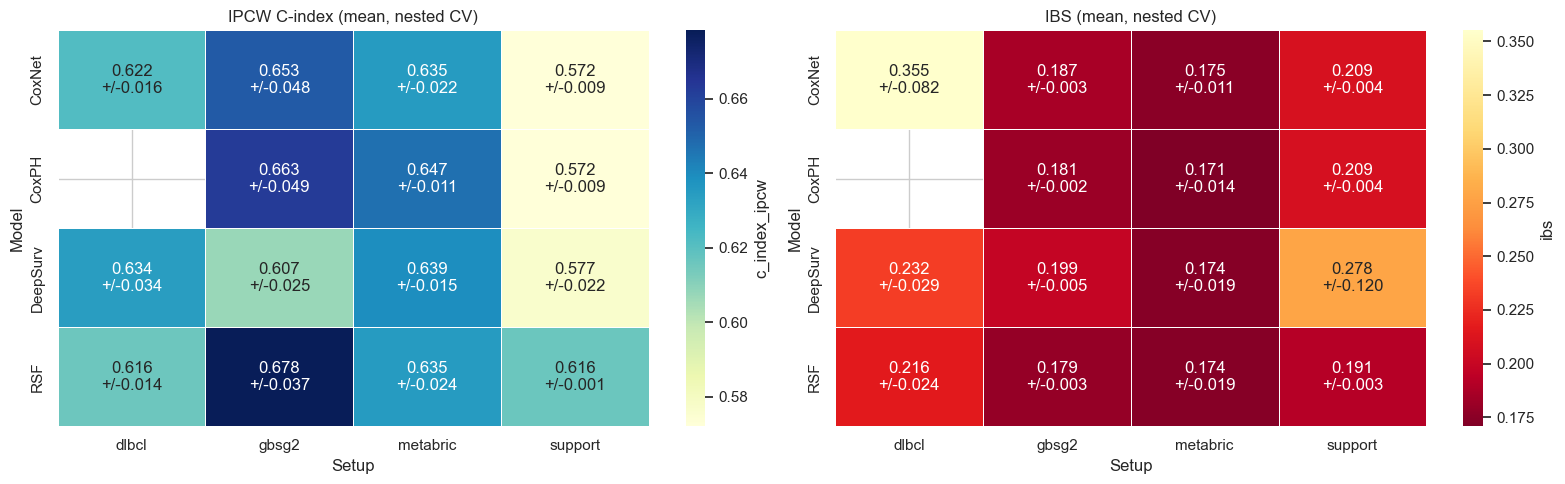

In [ ]:
# Metric heatmaps from nested CV
agg = cv_results.aggregate()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

try:
    plot_metric_heatmap(agg, 'c_index_ipcw', ax=axes[0])
    axes[0].set_title('IPCW C-index (mean, nested CV)')
except Exception as e:
    print(f'C-index heatmap error: {e}')

try:
    plot_metric_heatmap(agg, 'ibs', ax=axes[1], cmap='YlOrRd_r')
    axes[1].set_title('IBS (mean, nested CV)')
except Exception as e:
    print(f'IBS heatmap error: {e}')

fig.tight_layout()
plt.show()

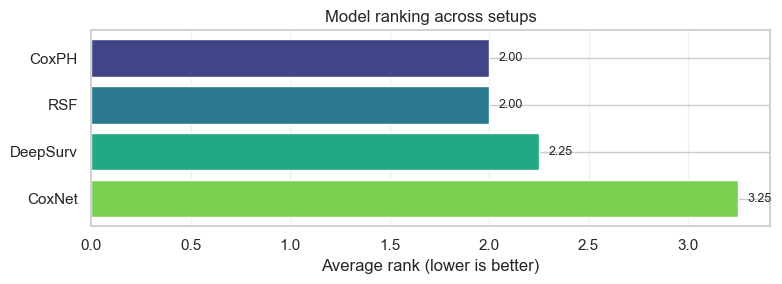

Model rankings (IPCW C-index):


,model,dlbcl_rank,gbsg2_rank,metabric_rank,support_rank,avg_rank
0,CoxPH,NaN,2.0,1.0,3.0,2.00
1,RSF,3.0,1.0,3.0,1.0,2.00
2,DeepSurv,1.0,4.0,2.0,2.0,2.25
3,CoxNet,2.0,3.0,4.0,4.0,3.25


In [ ]:
# Model ranking chart (by IPCW C-index)
rank_df = cv_results.rank_table('c_index_ipcw')
fig = plot_rank_chart(rank_df)
plt.show()

print('Model rankings (IPCW C-index):')
display(rank_df)

### Refitting with Best Hyperparameters

Nested CV provides unbiased performance estimates, but the models trained inside the folds are discarded after evaluation. For the detailed analyses that follow (Brier score curves, calibration plots, time-dependent AUC, CoxNet sparsity), we need fitted model objects on a fixed train/test split.

Below we extract the best hyperparameter configuration found during inner CV for each (dataset, model) pair and refit on a single stratified 80/20 split. This is standard practice: nested CV gives the metrics, the refitted models give the visualizations.

In [ ]:
import ast as _ast
from src.data.loaders import SKIP

# For each (dataset, model): pick best_config from fold with highest inner_cv_score,
# then refit on the same 80/20 train split. These tuned_models are used in
# all subsequent chapters (Brier, Calibration, Per-Dataset, etc.).

cv_df = cv_results.to_dataframe()

tuned_models = {}   # {ds_name: {mname: fitted_model}}
tuned_splits  = {}  # {ds_name: split arrays}

for ds_name in list(LOADERS.keys()):
    data = LOADERS[ds_name]()
    X_tr, X_te, T_tr, T_te, E_tr, E_te = train_test_split(
        data.X, data.T, data.E,
        test_size=0.2, random_state=SEED, stratify=data.E.astype(int),
    )
    tuned_splits[ds_name] = dict(
        X_tr=X_tr, X_te=X_te, T_tr=T_tr, T_te=T_te, E_tr=E_tr, E_te=E_te,
        feature_names=data.feature_names,
    )
    tuned_models[ds_name] = {}

    for mname in list(ALL_MODELS.keys()):
        model_class = ALL_MODELS[mname]
        display_name = getattr(model_class, "name", mname)
        if (ds_name, display_name) in SKIP:
            print(f"  SKIP {display_name} on {ds_name}")
            continue

        # Find fold with best inner_cv_score
        mask = (cv_df["setup"] == ds_name) & (cv_df["model"] == display_name)
        rows = cv_df[mask].copy()
        if rows.empty or "best_config" not in rows.columns:
            best_config = {}
        else:
            rows = rows.dropna(subset=["best_config", "inner_cv_score"])
            if rows.empty:
                best_config = {}
            else:
                best_row = rows.loc[rows["inner_cv_score"].idxmax()]
                try:
                    best_config = _ast.literal_eval(best_row["best_config"])
                except Exception:
                    best_config = {}

        try:
            model = model_class(**best_config)
            model.fit(X_tr, T_tr, E_tr)
            tuned_models[ds_name][mname] = model
            print(f"  {ds_name}/{display_name}: {best_config}")
        except Exception as e:
            print(f"  ERROR {ds_name}/{display_name}: {e}")

print("Tuned models ready.")

  gbsg2/CoxPH: {'alpha': 0.01, 'ties': 'breslow'}
  gbsg2/CoxNet: {'l1_ratio': 0.5, 'alpha_min_ratio': 0.001054057391055184, 'n_alphas': 100}
  gbsg2/RSF: {'n_estimators': 200, 'max_features': 0.5, 'min_samples_leaf': 10, 'max_depth': None, 'min_samples_split': 20}
  gbsg2/DeepSurv: {'hidden_layers': [128, 128, 128], 'dropout': 0.2, 'lr': 0.0001, 'weight_decay': 0, 'batch_size': 128}
  metabric/CoxPH: {'alpha': 0.01, 'ties': 'breslow'}
  metabric/CoxNet: {'l1_ratio': 0.75, 'alpha_min_ratio': 0.001180696500361215, 'n_alphas': 50}
  metabric/RSF: {'n_estimators': 500, 'max_features': 0.33, 'min_samples_leaf': 20, 'max_depth': 10, 'min_samples_split': 10}
  metabric/DeepSurv: {'hidden_layers': [128, 128, 128], 'dropout': 0.1, 'lr': 0.0003, 'weight_decay': 0.0001, 'batch_size': 128}
  SKIP CoxPH on dlbcl
  dlbcl/CoxNet: {'l1_ratio': 0.5, 'alpha_min_ratio': 0.001054057391055184, 'n_alphas': 100}
  dlbcl/RSF: {'n_estimators': 300, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'max_depth': 

---
## 4. Brier Score Over Time & Calibration

Time-resolved evaluation on all 4 datasets. Brier score curves show how well-calibrated each model is across the time horizon. Calibration plots compare predicted vs observed survival at the median event time. CoxPH is excluded from DLBCL (p >> n).

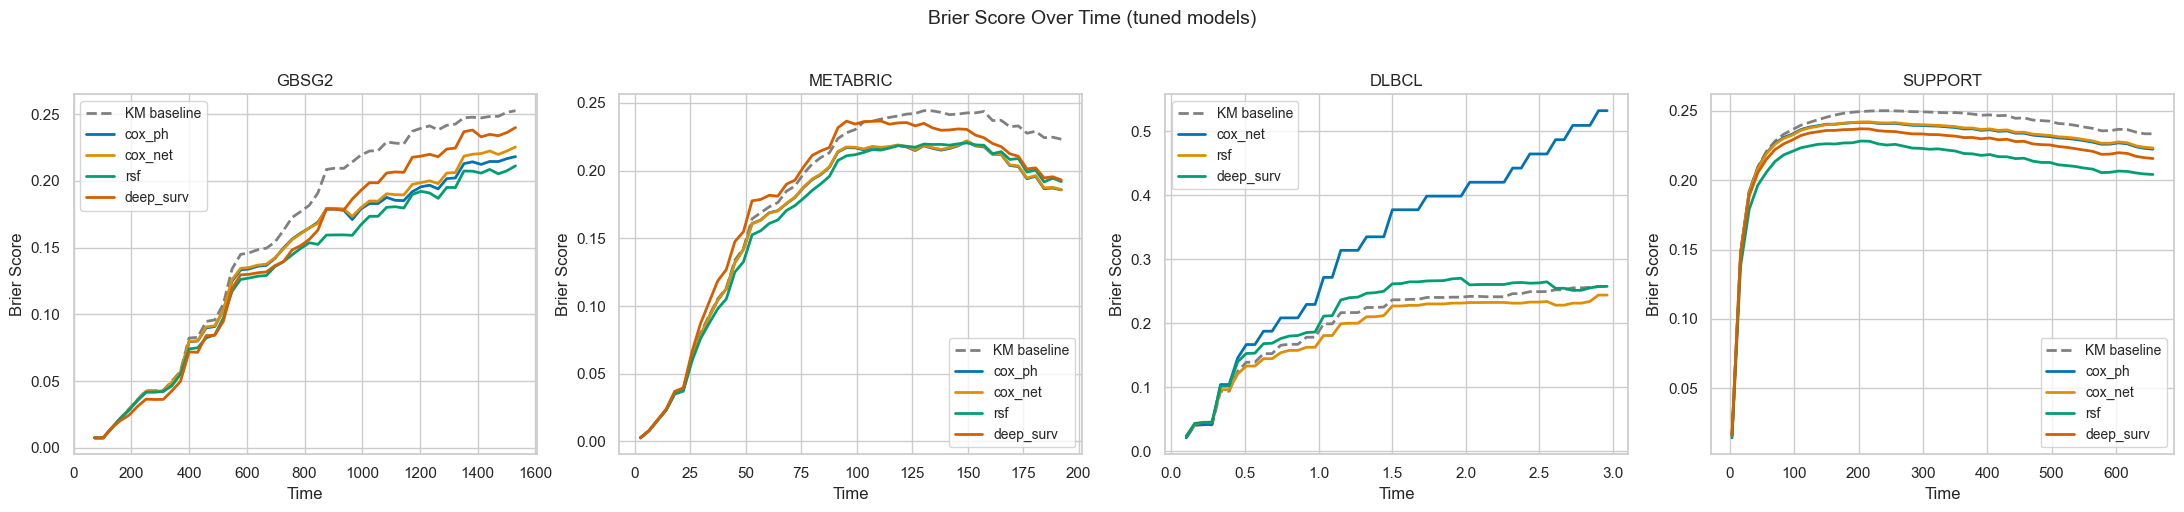

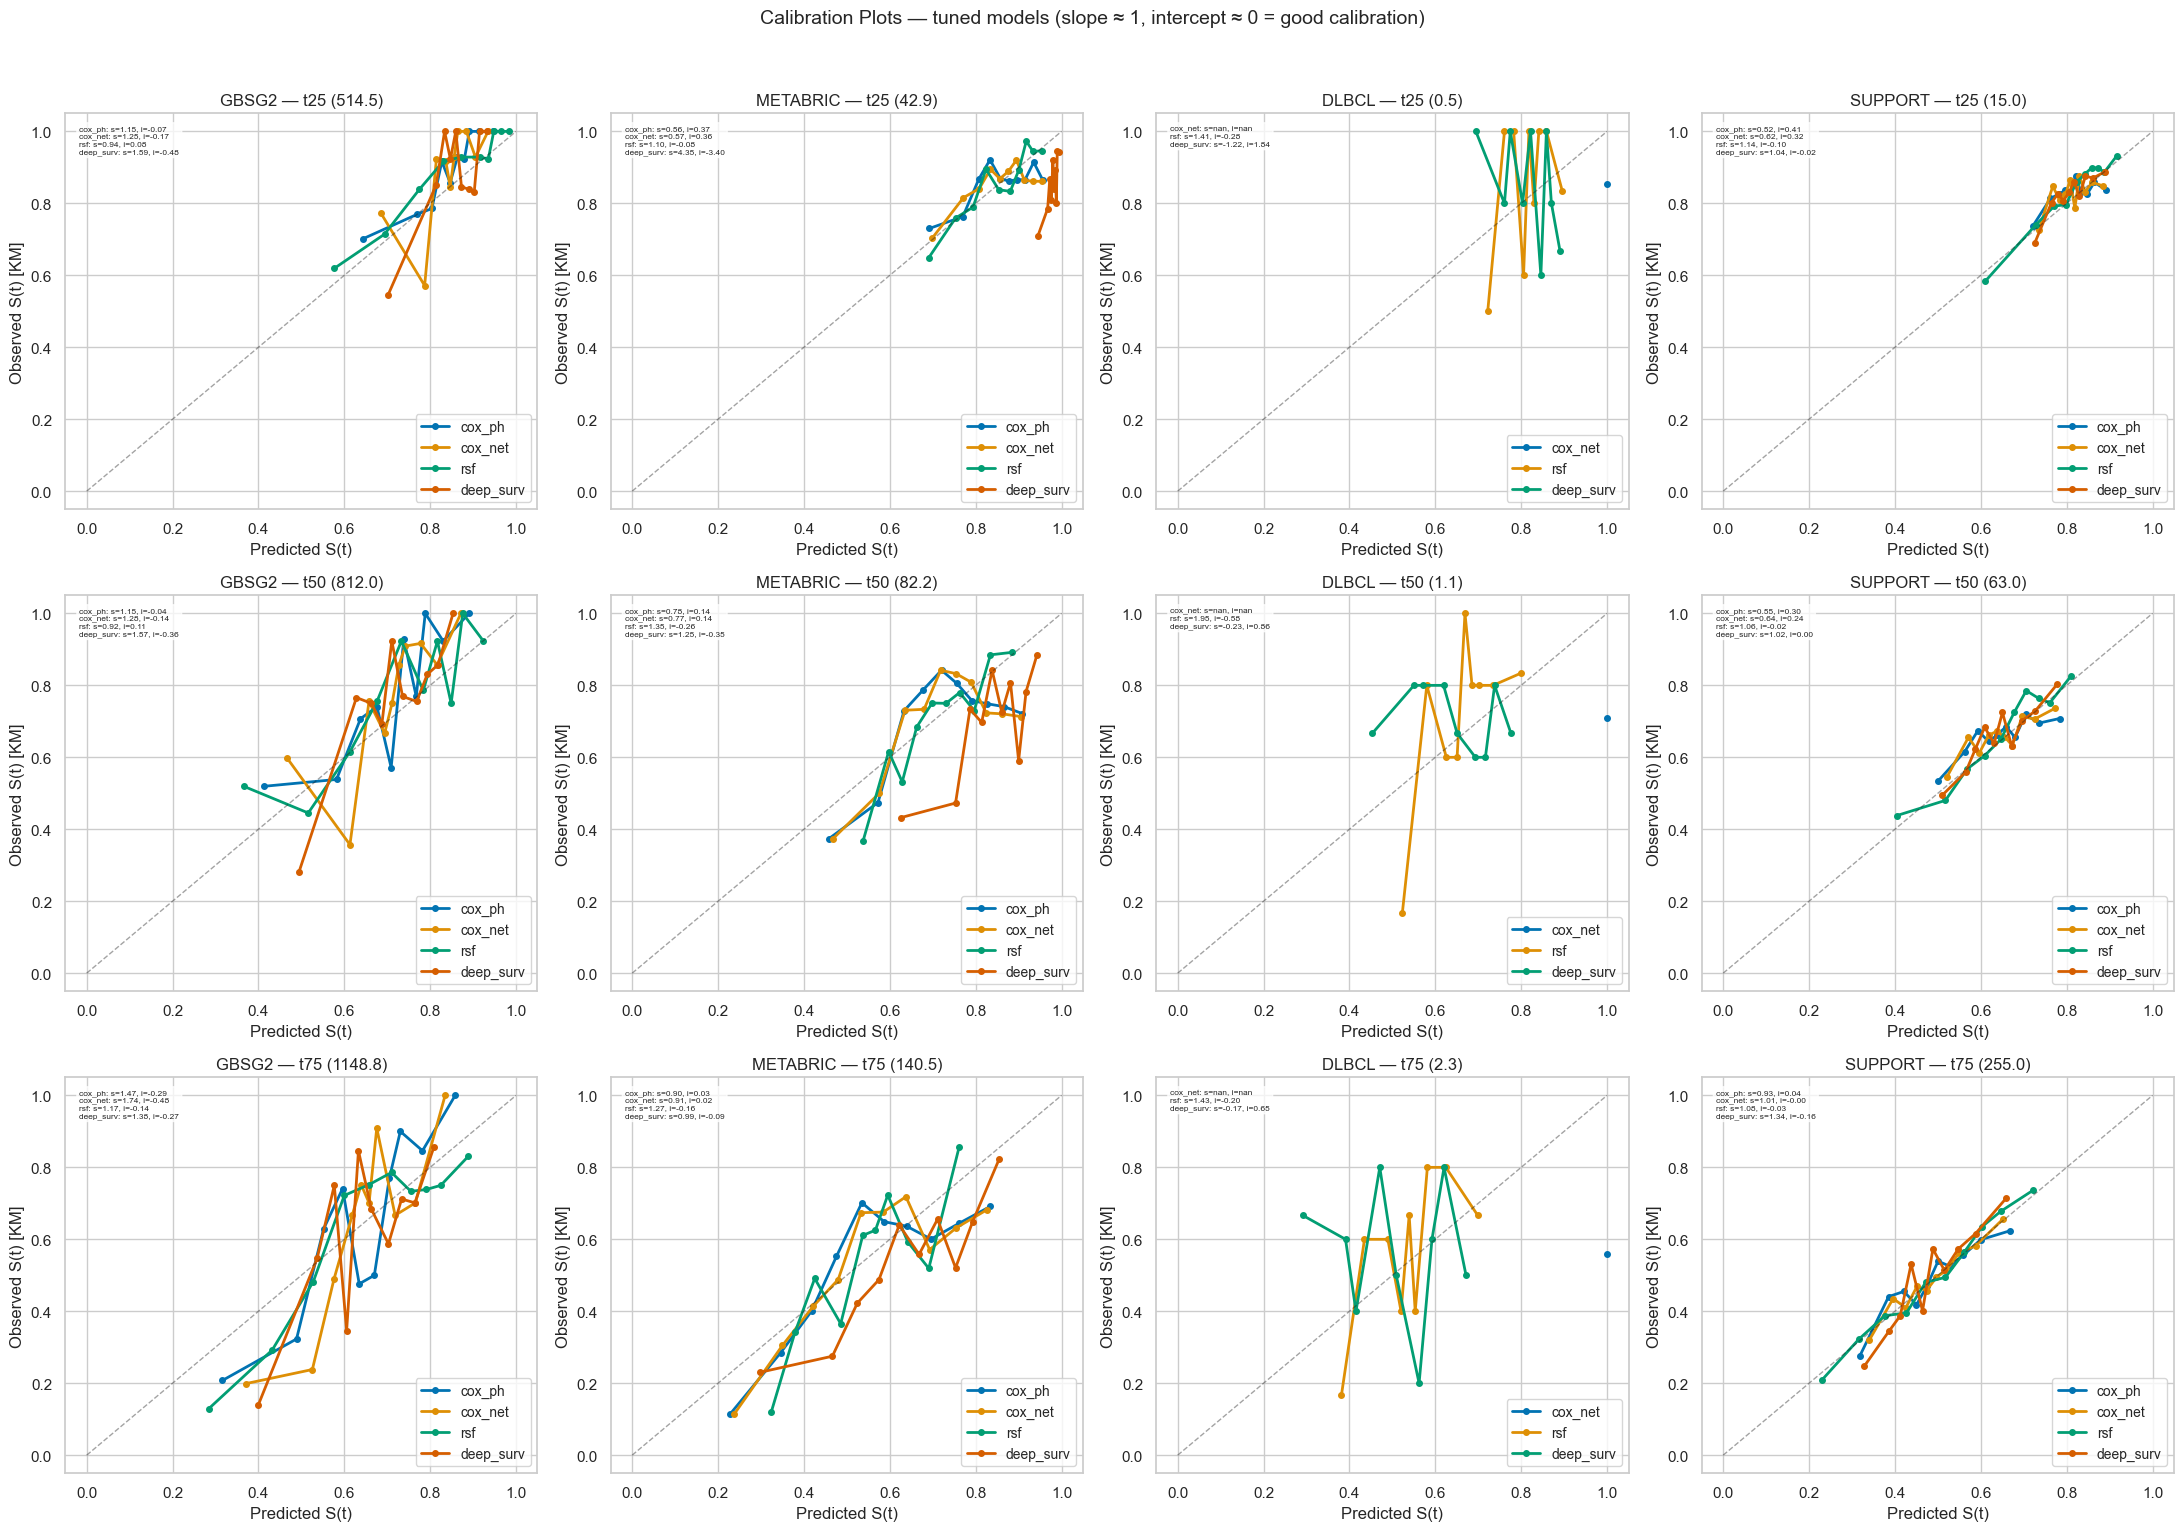

In [ ]:
from sksurv.metrics import brier_score as _brier_score_at_times
from sksurv.util import Surv
from lifelines import KaplanMeierFitter

eval_datasets = list(LOADERS.keys())
DATASET_MODELS = {
    "gbsg2":    ["cox_ph", "cox_net", "rsf", "deep_surv"],
    "metabric": ["cox_ph", "cox_net", "rsf", "deep_surv"],
    "support":  ["cox_ph", "cox_net", "rsf", "deep_surv"],
    "dlbcl":    ["cox_net", "rsf", "deep_surv"],  # CoxPH skipped (p >> n)
}
CAL_PERCENTILES = [25, 50, 75]

# Use tuned_models and tuned_splits from chapter 3
ds_cache = {}
for ds_name in eval_datasets:
    sp = tuned_splits[ds_name]
    X_tr, X_te = sp["X_tr"], sp["X_te"]
    T_tr, T_te = sp["T_tr"], sp["T_te"]
    E_tr, E_te = sp["E_tr"], sp["E_te"]
    ipcw_mask = T_te <= T_tr.max()
    X_te_f = X_te[ipcw_mask]; T_te_f = T_te[ipcw_mask]; E_te_f = E_te[ipcw_mask]
    ev_f = T_te_f[E_te_f.astype(bool)]
    times = np.linspace(max(ev_f.min(), 1e-6), np.percentile(ev_f, 90), 50)
    t_cal_points = np.percentile(ev_f, CAL_PERCENTILES)
    y_tr   = Surv.from_arrays(E_tr.astype(bool), T_tr)
    y_te_f = Surv.from_arrays(E_te_f.astype(bool), T_te_f)

    # KM baseline: covariate-free survival curve from training data
    kmf = KaplanMeierFitter()
    kmf.fit(T_tr, event_observed=E_tr)
    km_surv = np.array([kmf.predict(t) for t in times])  # (len(times),)
    km_surv_matrix = np.tile(km_surv, (len(X_te_f), 1))   # (n_test, len(times))

    ds_cache[ds_name] = dict(
        X_tr=X_tr, X_te=X_te, T_tr=T_tr, T_te=T_te, E_tr=E_tr, E_te=E_te,
        X_te_f=X_te_f, T_te_f=T_te_f, E_te_f=E_te_f,
        times=times, t_cal_points=t_cal_points,
        y_tr=y_tr, y_te_f=y_te_f,
        km_surv_matrix=km_surv_matrix,
        fitted=tuned_models[ds_name],
    )

# Figure 1: Brier score over time (1 x 4)
fig1, axes1 = plt.subplots(1, 4, figsize=(22, 5))
for ax, ds_name in zip(axes1, eval_datasets):
    c = ds_cache[ds_name]

    # KM baseline (no covariates)
    try:
        _, bs_km = _brier_score_at_times(c["y_tr"], c["y_te_f"], c["km_surv_matrix"], c["times"])
        ax.plot(c["times"], bs_km, label="KM baseline", linewidth=2, linestyle="--", color="gray")
    except Exception as e:
        print(f"{ds_name} KM baseline brier: {e}")

    for mname, model in c["fitted"].items():
        try:
            surv = model.predict_survival_function(c["X_te_f"], c["times"])
            _, bs = _brier_score_at_times(c["y_tr"], c["y_te_f"], surv, c["times"])
            ax.plot(c["times"], bs, label=mname, linewidth=2)
        except Exception as e:
            print(f"{ds_name} {mname} brier: {e}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Brier Score")
    ax.set_title(ds_name.upper())
    ax.legend(fontsize="small")
fig1.suptitle("Brier Score Over Time (tuned models)", fontsize=14, y=1.02)
fig1.tight_layout()
plt.show()

# Figure 2: Calibration at t25 / t50 / t75 (3 x 4)
fig2, axes2 = plt.subplots(3, 4, figsize=(22, 15))
for row, pct in enumerate(CAL_PERCENTILES):
    for col, ds_name in enumerate(eval_datasets):
        ax = axes2[row, col]
        c = ds_cache[ds_name]
        t_cal = c["t_cal_points"][row]
        slope_lines = []
        for mname, model in c["fitted"].items():
            try:
                surv_at_t = model.predict_survival_function(c["X_te"], np.array([t_cal]))[:, 0]
                pred_means, obs_surv, slope, intercept = calibration_curve(
                    c["T_te"], c["E_te"], surv_at_t, t_cal, n_bins=10
                )
                valid = ~(np.isnan(pred_means) | np.isnan(obs_surv))
                ax.plot(pred_means[valid], obs_surv[valid], "o-", label=mname, linewidth=2, markersize=4)
                slope_lines.append(f"{mname}: s={slope:.2f}, i={intercept:.2f}")
            except Exception as e:
                print(f"{ds_name} {mname} calib t{pct}: {e}")
        ax.plot([0, 1], [0, 1], "k--", alpha=0.4, linewidth=1)
        ax.set_xlabel("Predicted S(t)")
        ax.set_ylabel("Observed S(t) [KM]")
        ax.set_title(f"{ds_name.upper()} — t{pct} ({t_cal:.1f})")
        ax.legend(fontsize="small")
        if slope_lines:
            textstr = chr(10).join(slope_lines)
            ax.text(0.03, 0.97, textstr, transform=ax.transAxes, fontsize=6,
                    verticalalignment="top",
                    bbox=dict(boxstyle="round", facecolor="white", alpha=0.75))
fig2.suptitle("Calibration Plots — tuned models (slope ≈ 1, intercept ≈ 0 = good calibration)", fontsize=14, y=1.02)
fig2.tight_layout()
plt.show()

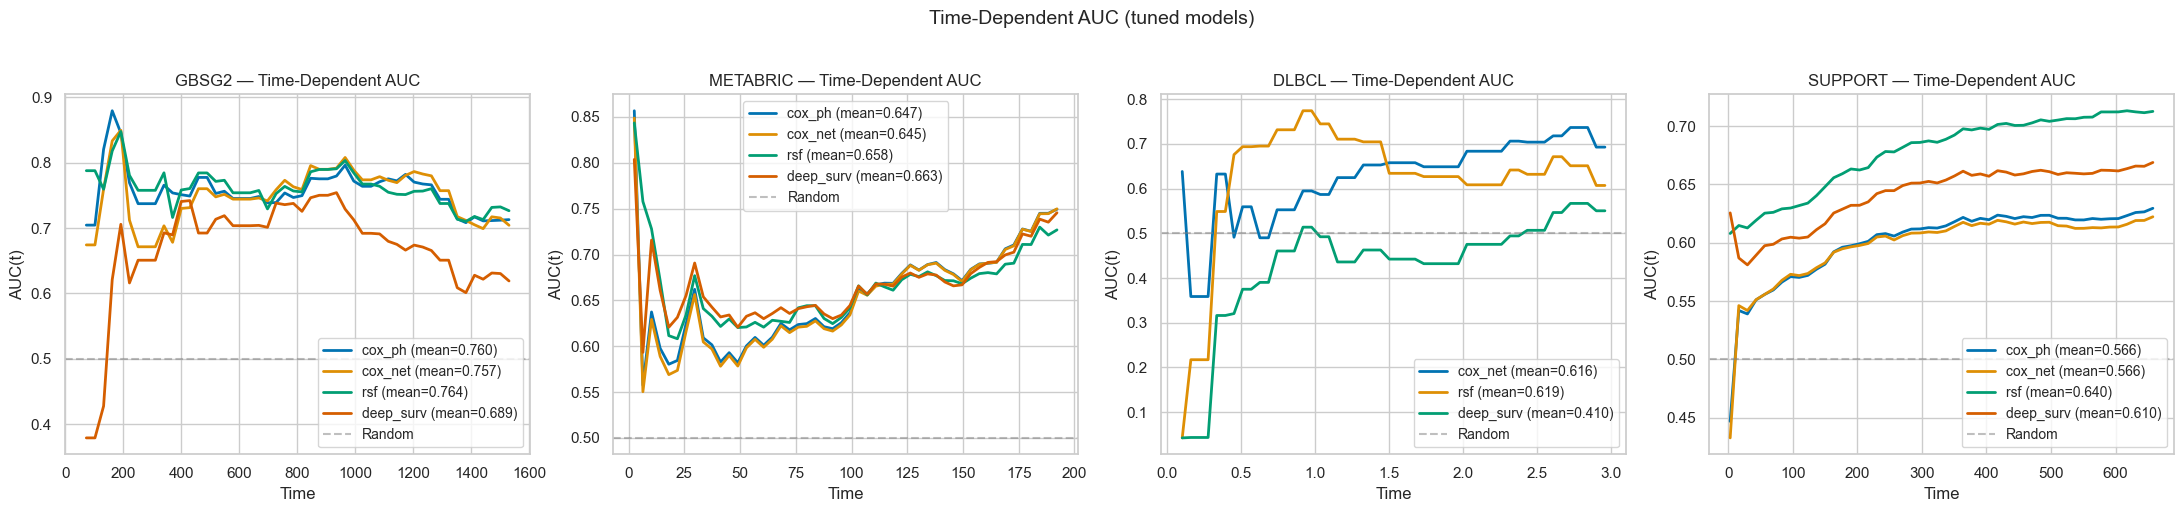

In [ ]:
# Time-dependent AUC — all datasets (tuned models)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, ds_name in zip(axes, eval_datasets):
    c = ds_cache[ds_name]
    model_list = DATASET_MODELS[ds_name]

    for mname in model_list:
        if mname not in c["fitted"]:
            continue
        try:
            model = c["fitted"][mname]
            risk = model.predict_risk(c["X_te_f"])
            auc_vals, mean_auc = time_dependent_auc(
                c["T_tr"], c["E_tr"], c["T_te_f"], c["E_te_f"], risk, c["times"]
            )
            ax.plot(c["times"], auc_vals, label=f'{mname} (mean={mean_auc:.3f})', linewidth=2)
        except Exception as e:
            print(f'{ds_name} {mname}: {e}')

    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
    ax.set_xlabel('Time')
    ax.set_ylabel('AUC(t)')
    ax.set_title(f'{ds_name.upper()} — Time-Dependent AUC')
    ax.legend(fontsize='small')

fig.suptitle("Time-Dependent AUC (tuned models)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

### DLBCL: CoxNet Coefficient Sparsity

DLBCL is the only high-dimensional dataset in our benchmark (p=7,399 features, n=240 samples). Unpenalised Cox regression is infeasible here (p >> n), but CoxNet's elastic-net penalty should shrink most coefficients to zero, selecting a sparse set of prognostically relevant genes. This section examines whether the tuned CoxNet model achieves meaningful sparsity and which features it selects — a practical demonstration of regularization in survival analysis.

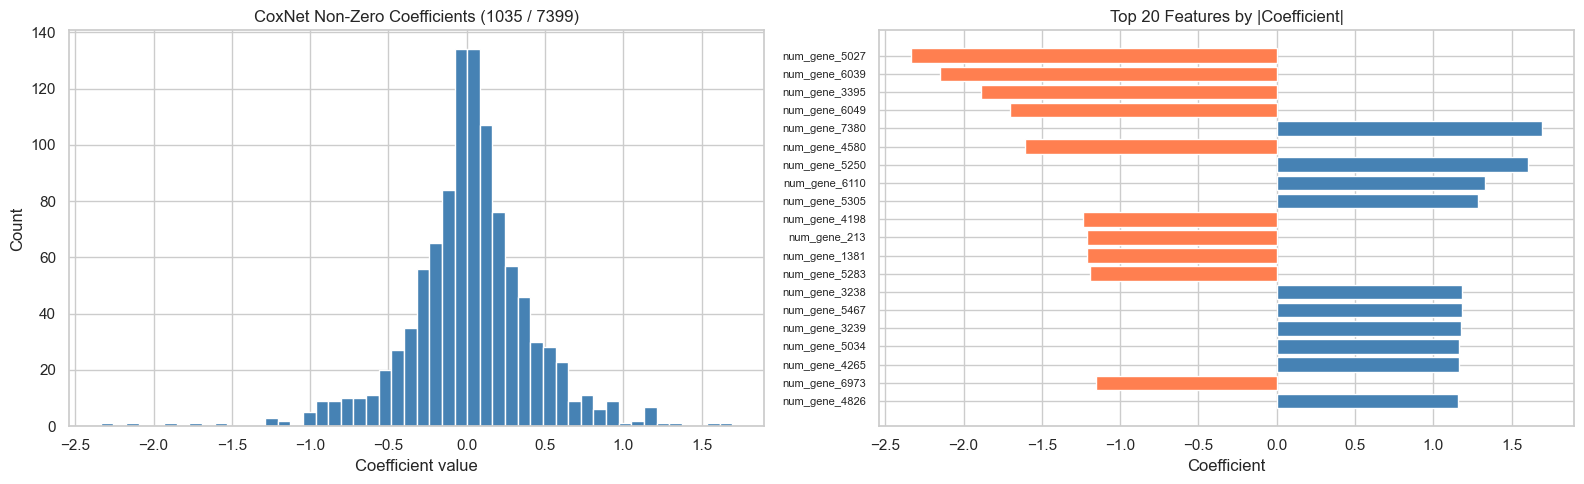

DLBCL: 1035 non-zero coefficients out of 7399 features (14.0%)


In [ ]:
# CoxNet coefficient sparsity on DLBCL
from src.models.cox_net import CoxNetModel

dlbcl_data = datasets['dlbcl']
# Use tuned CoxNet from chapter 3
coxnet = tuned_models["dlbcl"].get("cox_net")
if coxnet is None:
    coxnet = CoxNetModel()
    coxnet.fit(dlbcl_data.X, dlbcl_data.T, dlbcl_data.E)

# coef_ is (p, n_alphas); last column = smallest alpha (default for predict)
coefs = coxnet._model.coef_[:, -1]
nonzero = int(np.sum(np.abs(coefs) > 1e-8))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Coefficient distribution (non-zero only)
axes[0].hist(coefs[np.abs(coefs) > 1e-8], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Coefficient value')
axes[0].set_ylabel('Count')
axes[0].set_title(f'CoxNet Non-Zero Coefficients ({nonzero} / {dlbcl_data.p})')

# Top 20 features by |coefficient|
top_idx = np.argsort(np.abs(coefs))[::-1][:20]
top_names = [dlbcl_data.feature_names[i] for i in top_idx]
top_vals = coefs[top_idx]
bar_colors = ['coral' if v < 0 else 'steelblue' for v in top_vals]
axes[1].barh(range(len(top_names)), top_vals, color=bar_colors)
axes[1].set_yticks(range(len(top_names)))
axes[1].set_yticklabels(top_names, fontsize=8)
axes[1].set_xlabel('Coefficient')
axes[1].set_title('Top 20 Features by |Coefficient|')
axes[1].invert_yaxis()

fig.tight_layout()
plt.show()

print(f'DLBCL: {nonzero} non-zero coefficients out of {dlbcl_data.p} features ({nonzero/dlbcl_data.p:.1%})')

---
## 6. Summary & Export

In [ ]:
# 2x2 summary figure — all panels use nested CV results
cv_agg = cv_results.aggregate()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (0,0) IPCW C-index heatmap (Nested CV, mean)
if 'c_index_ipcw_mean' in cv_agg.columns:
    pivot = cv_agg.pivot_table(index='model', columns='setup', values='c_index_ipcw_mean')
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Greens', ax=axes[0, 0], linewidths=0.5)
    axes[0, 0].set_title('IPCW C-index (Nested CV)')
    axes[0, 0].set_ylabel('')

# (0,1) IBS heatmap (Nested CV, mean)
if 'ibs_mean' in cv_agg.columns:
    pivot = cv_agg.pivot_table(index='model', columns='setup', values='ibs_mean')
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='Reds_r', ax=axes[0, 1], linewidths=0.5)
    axes[0, 1].set_title('Integrated Brier Score (Nested CV)')
    axes[0, 1].set_ylabel('')

# (1,0) Fit time (Nested CV, mean)
if 'fit_time_s_mean' in cv_agg.columns:
    pivot_time = cv_agg.pivot_table(index='model', columns='setup', values='fit_time_s_mean')
    pivot_time.plot(kind='bar', ax=axes[1, 0], width=0.8, legend=True)
    axes[1, 0].set_ylabel('Seconds')
    axes[1, 0].set_title('Training Time (Nested CV, mean)')
    axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)
    axes[1, 0].legend(fontsize='small')

# (1,1) Rank chart from nested CV
try:
    rank_df = cv_results.rank_table('c_index_ipcw')
    if not rank_df.empty:
        models = rank_df['model'].values
        avg_ranks = rank_df['avg_rank'].values
        bar_colors = sns.color_palette('colorblind', len(models))
        axes[1, 1].barh(models, avg_ranks, color=bar_colors)
        axes[1, 1].set_xlabel('Average Rank')
        axes[1, 1].set_title('Model Rankings (Nested CV, IPCW C-index)')
        axes[1, 1].invert_yaxis()
except Exception:
    axes[1, 1].text(0.5, 0.5, 'Nested CV results\nnot available', ha='center', va='center')

fig.suptitle('Experiment Summary (Nested CV)', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

In [ ]:
# Save all results
df_bench.to_csv(str(RESULTS_DIR / 'benchmark_results.csv'), index=False)
print(f'Saved: {RESULTS_DIR / "benchmark_results.csv"}')

try:
    cv_df = cv_results.to_dataframe()
    cv_df.to_csv(str(RESULTS_DIR / 'nested_cv_raw.csv'), index=False)
    print(f'Saved: {RESULTS_DIR / "nested_cv_raw.csv"}')

    cv_agg = cv_results.aggregate()
    cv_agg.to_csv(str(RESULTS_DIR / 'nested_cv_aggregated.csv'), index=False)
    print(f'Saved: {RESULTS_DIR / "nested_cv_aggregated.csv"}')
except Exception as e:
    print(f'CV results save error: {e}')

print('\nDone.')